In [109]:
#importing the dependies

In [110]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
#Data Collection and processing

In [112]:
#loading the dataset
heart_dataset=pd.read_csv(r"D:\Final Year Project\Data\heart_disease_data.csv")

In [113]:
heart_dataset.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [114]:
heart_dataset.shape

(303, 14)

In [115]:
heart_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [116]:
heart_dataset.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [117]:
duplicates = heart_dataset.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 1


In [118]:
heart_dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [119]:
heart_dataset['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

C:\Users\Ikram Micro\AppData\Local\Temp\ipykernel_9780\2779351703.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=heart_dataset, palette='Set2')


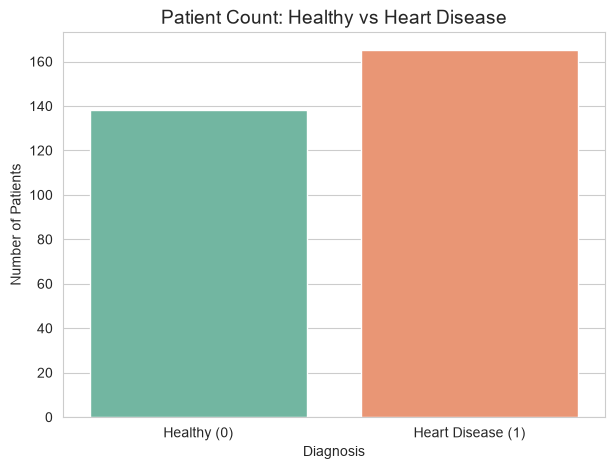

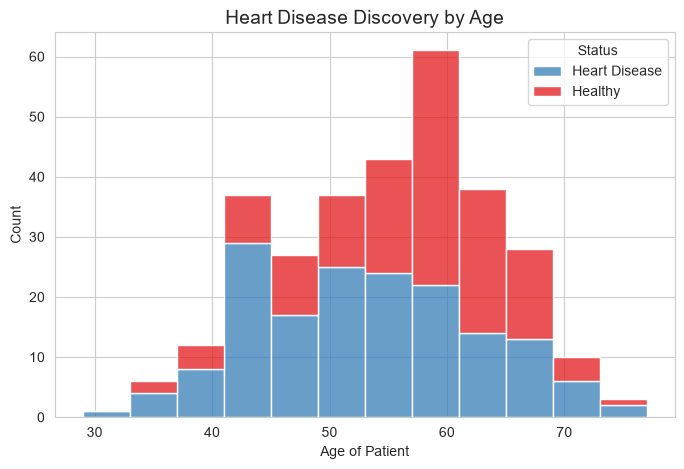

In [120]:

sns.set_style("whitegrid")

# --- PLOT 1: HOW MANY PEOPLE ARE SICK? ---
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='target', data=heart_dataset, palette='Set2')

# Explain to Supervisor: "This shows if our data is balanced."
plt.title('Patient Count: Healthy vs Heart Disease', fontsize=14)
plt.xticks([0, 1], ['Healthy (0)', 'Heart Disease (1)']) # Clearer labels
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.show()

# --- PLOT 2: DOES AGE MATTER? ---
plt.figure(figsize=(8, 5))
# 'hue' splits the bars by color (Healthy vs Sick)
sns.histplot(data=heart_dataset, x='age', hue='target', multiple="stack", palette='Set1')

plt.title('Heart Disease Discovery by Age', fontsize=14)
plt.xlabel('Age of Patient')
plt.ylabel('Count')
plt.legend(title='Status', labels=['Heart Disease', 'Healthy'])
plt.show()

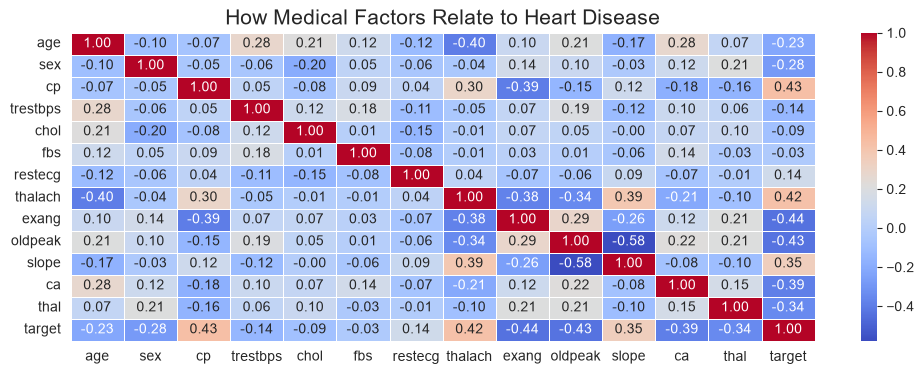

In [121]:
correlation_matrix = heart_dataset.corr()
plt.figure(figsize=(12, 4))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('How Medical Factors Relate to Heart Disease', fontsize=15)
plt.show()

In [122]:
#Splitting the Feature and Target

In [123]:
X = heart_dataset.drop('target', axis=1)
Y = heart_dataset['target']

In [124]:
print(X)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [125]:
print(Y)

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64


In [126]:
#splitting the data into training and testing data

In [127]:
from sklearn.preprocessing import OneHotEncoder
X = heart_dataset.drop('target', axis=1)
y = heart_dataset['target']
cat_cols = ['cp', 'thal', 'restecg', 'slope', 'ca']
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_array = encoder.fit_transform(X[cat_cols])
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(cat_cols))
X = pd.concat([X.drop(cat_cols, axis=1), encoded_df], axis=1)

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [129]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [130]:
print(X.shape,X_train_scaled.shape,X_test_scaled.shape)

(303, 22) (242, 22) (61, 22)


In [131]:
#Model Training

In [137]:
model=LogisticRegression(max_iter=4000,
    class_weight='balanced',  # Important for medical data
    solver='liblinear',
    random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


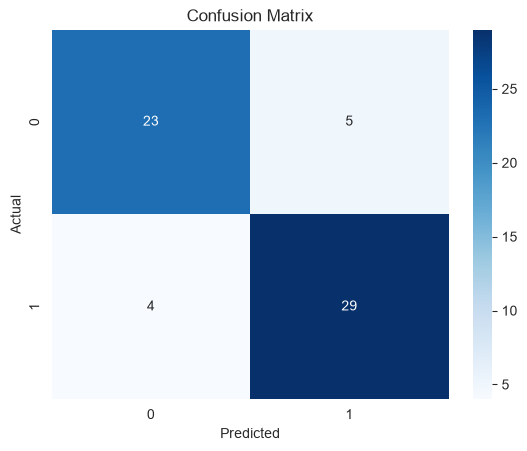

In [133]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [134]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"✅ Accuracy:  {accuracy:.2%}")
print(f"✅ Precision: {precision:.2%}")
print(f"✅ Recall:    {recall:.2%}")
print(f"✅ F1-Score:  {f1:.2%}")
print("\n📋 FULL CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Not Healthy']))

✅ Accuracy:  85.25%
✅ Precision: 85.29%
✅ Recall:    87.88%
✅ F1-Score:  86.57%

📋 FULL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     Healthy       0.85      0.82      0.84        28
 Not Healthy       0.85      0.88      0.87        33

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [135]:
feature_names = X.columns.tolist()

sample_index = 8
single_sample = X_test_scaled[sample_index].reshape(1, -1)

probabilities = model.predict_proba(single_sample)[0]
prediction = model.predict(single_sample)[0]

if prediction == 1:
    top_feature_idx = model.coef_[0].argmax()
    reason = feature_names[top_feature_idx]

    print("✅ AI Analysis Complete")
    print(f"Result: Not Healthy ({probabilities[1]:.2%} confidence)")
    print(f"XAI Explanation: The primary risk driver for this patient is '{reason}'.")
else:
    print(f"✅ Result: Healthy ({probabilities[0]:.2%} confidence)")

✅ AI Analysis Complete
Result: Not Healthy (99.54% confidence)
XAI Explanation: The primary risk driver for this patient is 'cp_2'.


In [138]:
import os
import pickle

models_path = r"D:\Final Year Project\backend\models"

# Save model
with open(f"{models_path}\\heart_disease_logistic_model.pkl", "wb") as f:
    pickle.dump(model, f)  # replace 'model' with your variable name

# Save scaler (REQUIRED)
with open(f"{models_path}\\heart_disease_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)  # replace 'scaler' with your variable name

with open(f"{models_path}\\heart_disease_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)    

print("Model size:", os.path.getsize(f"{models_path}\\heart_disease_logistic_model.pkl"), "bytes")
print("Scaler size:", os.path.getsize(f"{models_path}\\heart_disease_scaler.pkl"), "bytes")
print("Done!")

Model size: 858 bytes
Scaler size: 1238 bytes
Done!
